# ADS-GAN results

In this notebook we compare metrics results of ADS-GAN with CTGAN for five datasets:

1. Alzheimer's Disease
2. Coronary Artery Disease
3. Gallstones
4. Diabetes
5. Breast Cancer

Metrics dataframes.

In [6]:
import pandas as pd

adsgan_eval_alzheimers = pd.read_csv('metrics_results/adsgan/adsgan_eval_alzheimers.csv', index_col=0)
adsgan_eval_breast_cancer = pd.read_csv('metrics_results/adsgan/adsgan_eval_breast_cancer.csv', index_col=0)
adsgan_eval_coronary_artery = pd.read_csv('metrics_results/adsgan/adsgan_eval_coronary_artery.csv', index_col=0)
adsgan_eval_diabetes = pd.read_csv('metrics_results/adsgan/adsgan_eval_diabetes.csv', index_col=0)
adsgan_eval_gallstone = pd.read_csv('metrics_results/adsgan/adsgan_eval_gallstone.csv', index_col=0)

ctgan_eval_alzheimers = pd.read_csv('metrics_results/ctgan/ctgan_eval_alzheimers.csv', index_col=0)
ctgan_eval_breast_cancer = pd.read_csv('metrics_results/ctgan/ctgan_eval_breast_cancer.csv', index_col=0)
ctgan_eval_coronary_artery = pd.read_csv('metrics_results/ctgan/ctgan_eval_coronary_artery.csv', index_col=0)
ctgan_eval_diabetes = pd.read_csv('metrics_results/ctgan/ctgan_eval_diabetes.csv', index_col=0)
ctgan_eval_gallstone = pd.read_csv('metrics_results/ctgan/ctgan_eval_gallstone.csv', index_col=0)

In [7]:
adsgan_results = {
    'alzheimers': adsgan_eval_alzheimers,
    'breast_cancer': adsgan_eval_breast_cancer,
    'coronary_artery': adsgan_eval_coronary_artery,
    'diabetes': adsgan_eval_diabetes,
    'gallstone': adsgan_eval_gallstone
}

ctgan_results = {
    'alzheimers': ctgan_eval_alzheimers,
    'breast_cancer': ctgan_eval_breast_cancer,
    'coronary_artery': ctgan_eval_coronary_artery,
    'diabetes': ctgan_eval_diabetes,
    'gallstone': ctgan_eval_gallstone
}

In [8]:
import matplotlib.pyplot as plt
import numpy as np

DATASETS = ['alzheimers', 'breast_cancer', 'coronary_artery', 'diabetes', 'gallstone']
DATASET_LABELS = ["Alzheimer's", "Breast Cancer", "Coronary Artery", "Diabetes", "Gallstone"]
COLORS = {'ADS-GAN': '#2196F3', 'CTGAN': '#FF9800'}

def plot_metric_grouped(metric, title=None, figsize=(10, 4), fmt="{:.3f}", invert_better=False):
    """Bar chart with datasets on x-axis, one bar per model per dataset."""
    adsgan_vals = [adsgan_results[d].loc[metric, 'mean'] for d in DATASETS]
    ctgan_vals  = [ctgan_results[d].loc[metric, 'mean']  for d in DATASETS]

    x = np.arange(len(DATASETS))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)
    bars_a = ax.bar(x - width/2, adsgan_vals, width, label='ADS-GAN', color=COLORS['ADS-GAN'])
    bars_c = ax.bar(x + width/2, ctgan_vals,  width, label='CTGAN',   color=COLORS['CTGAN'])

    for bar in bars_a:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(bar.get_height()), ha='center', va='bottom', fontsize=8)
    for bar in bars_c:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(bar.get_height()), ha='center', va='bottom', fontsize=8)

    ax.set_title(title or metric)
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_LABELS)
    ax.legend()
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

## Fidelity / Statistical Similarity

Lower is better for JS distance, MMD, Wasserstein. Higher is better for the rest.

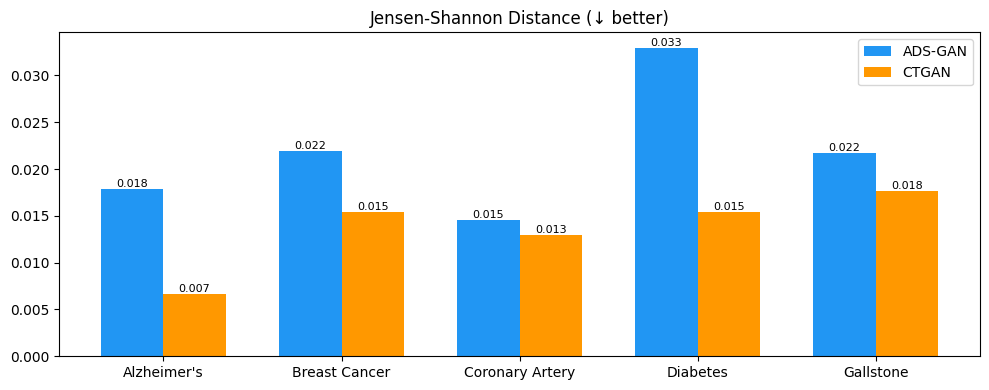

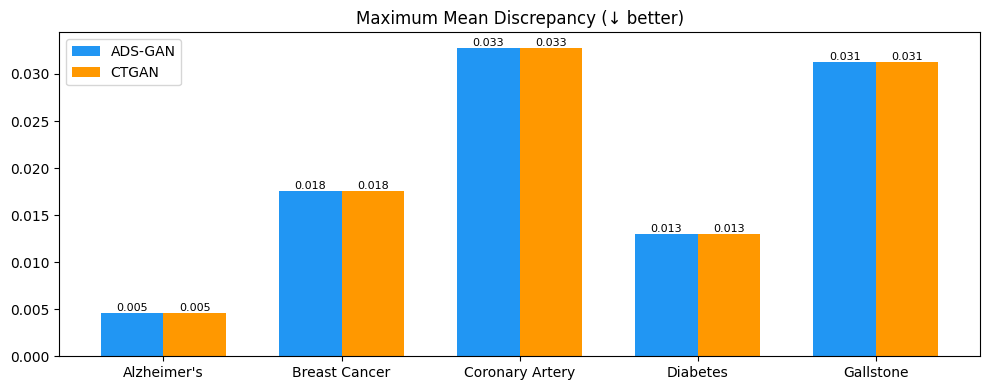

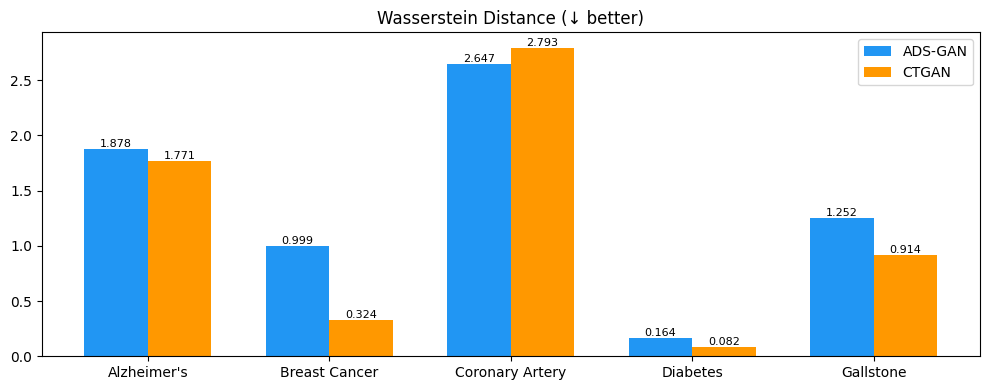

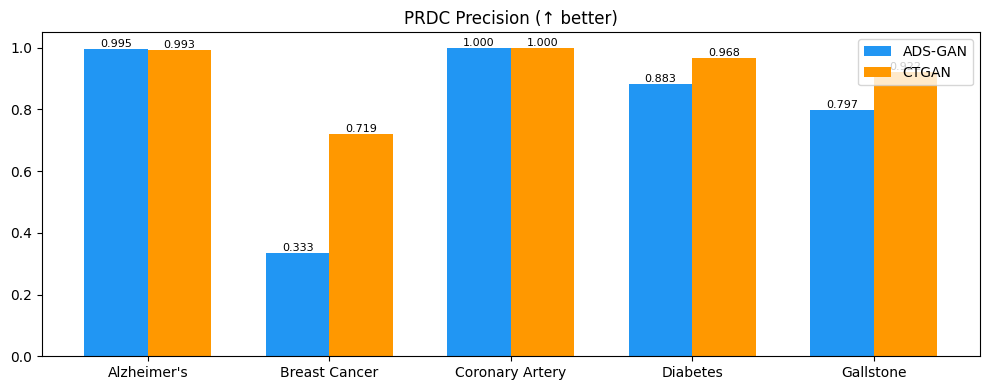

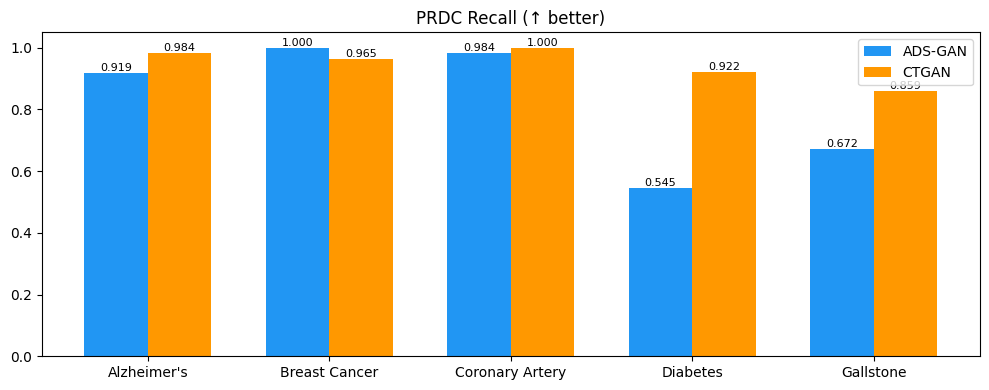

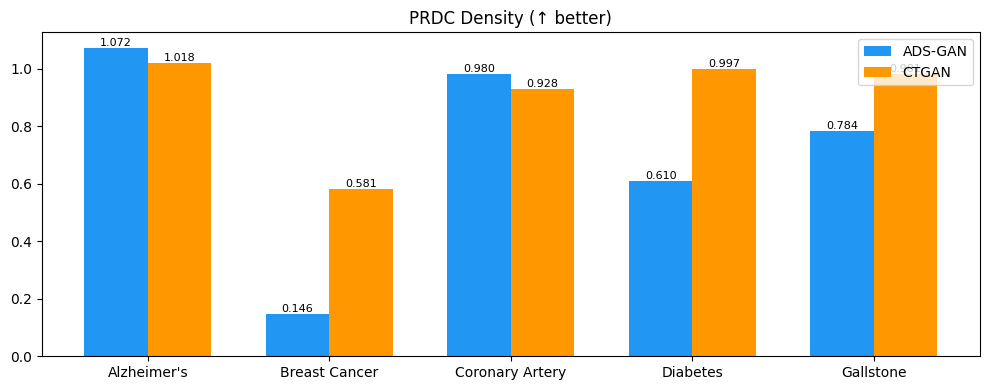

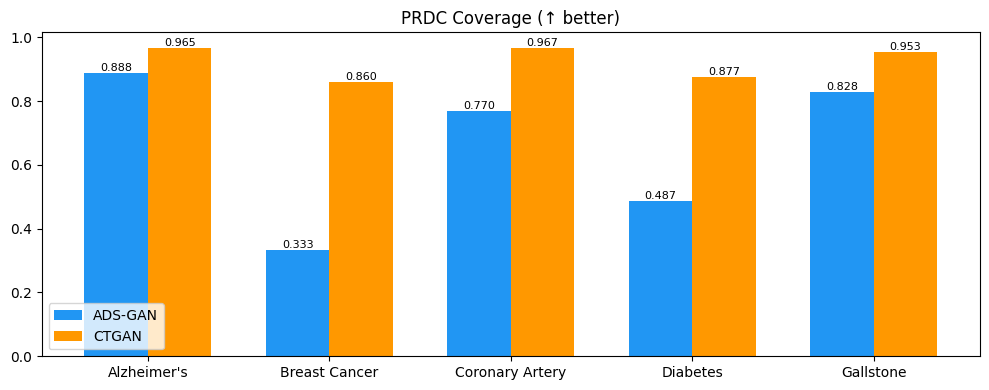

In [9]:
plot_metric_grouped('stats.jensenshannon_dist.marginal',  title='Jensen-Shannon Distance (↓ better)')
plot_metric_grouped('stats.max_mean_discrepancy.joint',   title='Maximum Mean Discrepancy (↓ better)')
plot_metric_grouped('stats.wasserstein_dist.joint',       title='Wasserstein Distance (↓ better)')
plot_metric_grouped('stats.prdc.precision',               title='PRDC Precision (↑ better)')
plot_metric_grouped('stats.prdc.recall',                  title='PRDC Recall (↑ better)')
plot_metric_grouped('stats.prdc.density',                 title='PRDC Density (↑ better)')
plot_metric_grouped('stats.prdc.coverage',                title='PRDC Coverage (↑ better)')

## Utility / Performance

`gt` = ground truth (real train → real test baseline).  
`syn_id` = train on synthetic, test on real (TSTR in-distribution).  
`syn_ood` = train on synthetic, test on held-out real (TSTR out-of-distribution).

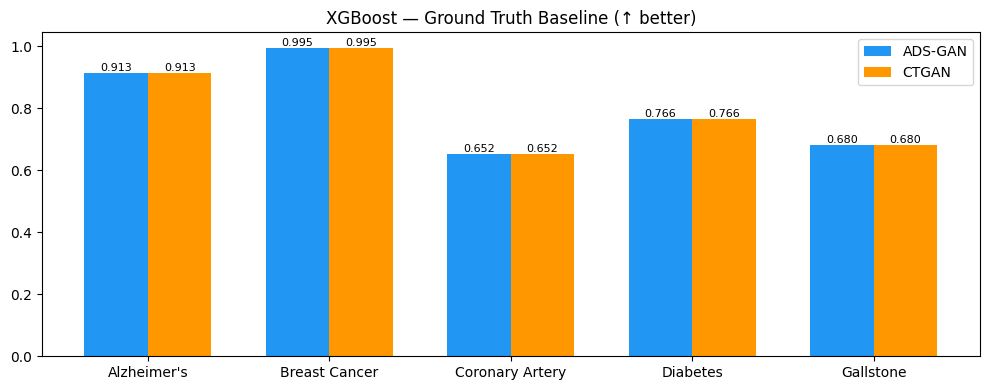

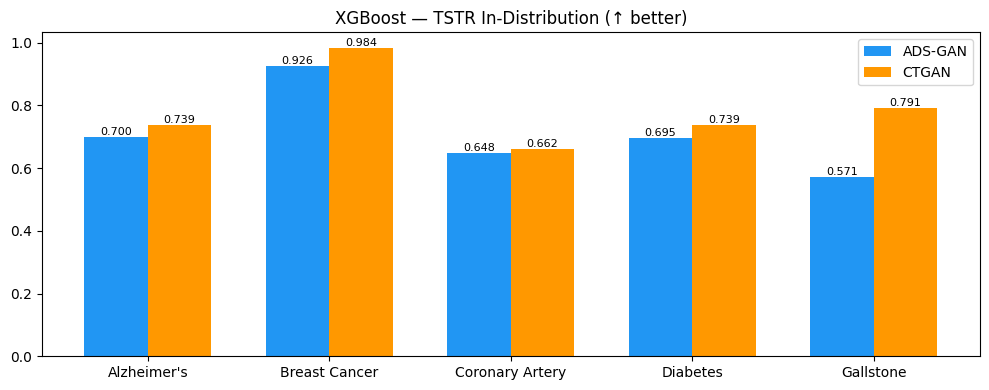

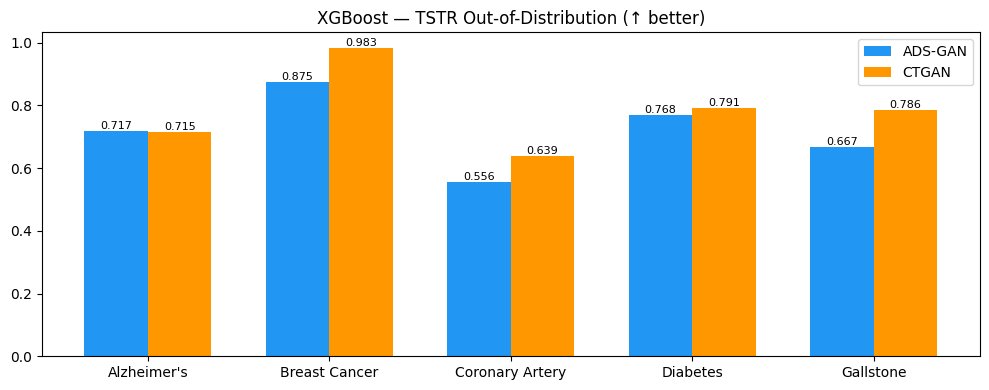

In [10]:
plot_metric_grouped('performance.xgb.gt',      title='XGBoost — Ground Truth Baseline (↑ better)')
plot_metric_grouped('performance.xgb.syn_id',  title='XGBoost — TSTR In-Distribution (↑ better)')
plot_metric_grouped('performance.xgb.syn_ood', title='XGBoost — TSTR Out-of-Distribution (↑ better)')

## Detection

How well a classifier can distinguish synthetic from real records. Score near 0.5 = indistinguishable (↓ better).

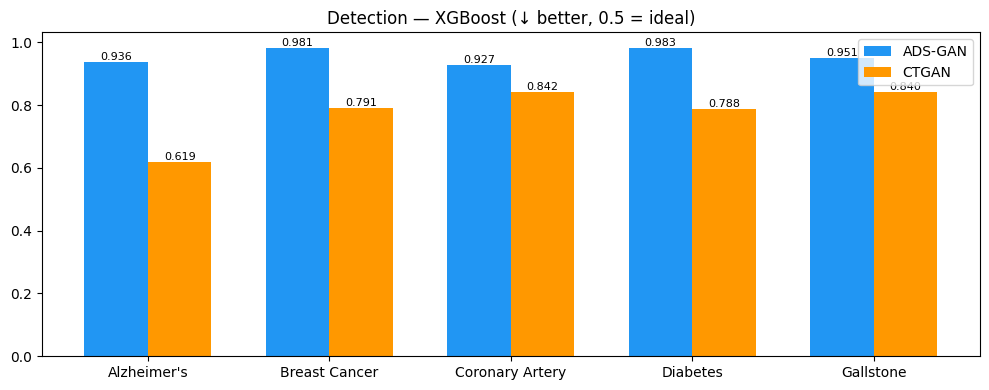

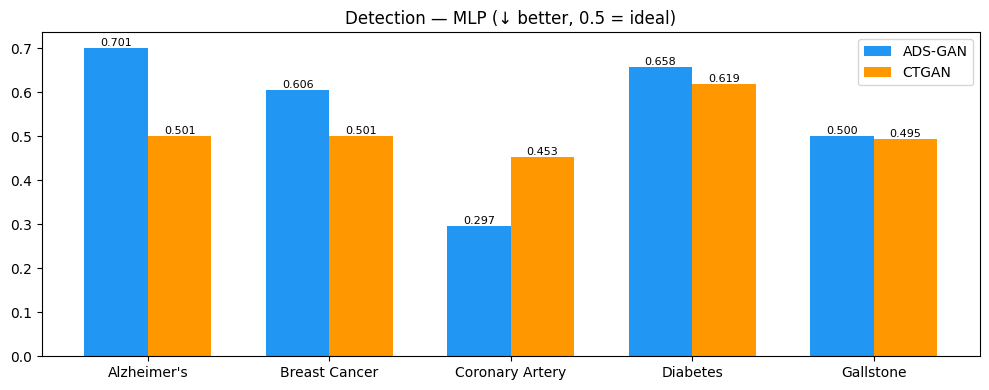

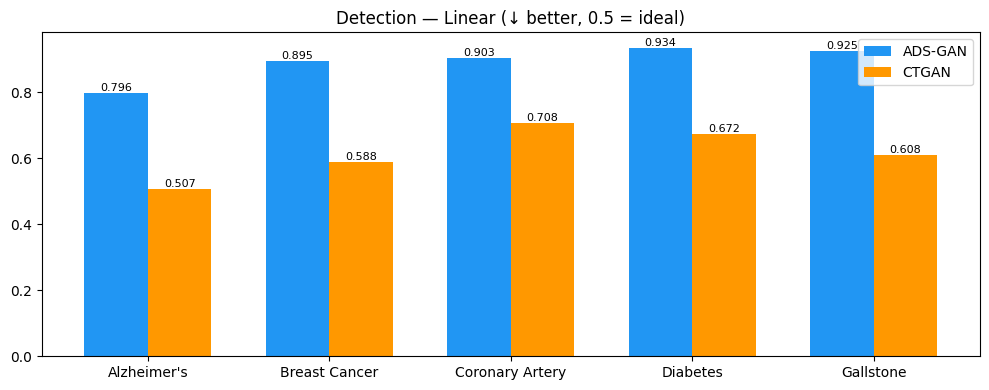

In [11]:
plot_metric_grouped('detection.detection_xgb.mean',    title='Detection — XGBoost (↓ better, 0.5 = ideal)')
plot_metric_grouped('detection.detection_mlp.mean',    title='Detection — MLP (↓ better, 0.5 = ideal)')
plot_metric_grouped('detection.detection_linear.mean', title='Detection — Linear (↓ better, 0.5 = ideal)')

## Privacy

`identifiability_score` — probability a synthetic record can be matched to a training record (↓ better).  
`DomiasMIA_BNAF` — membership inference attack AUC-ROC; near 0.5 = model does not leak membership (↓ better).

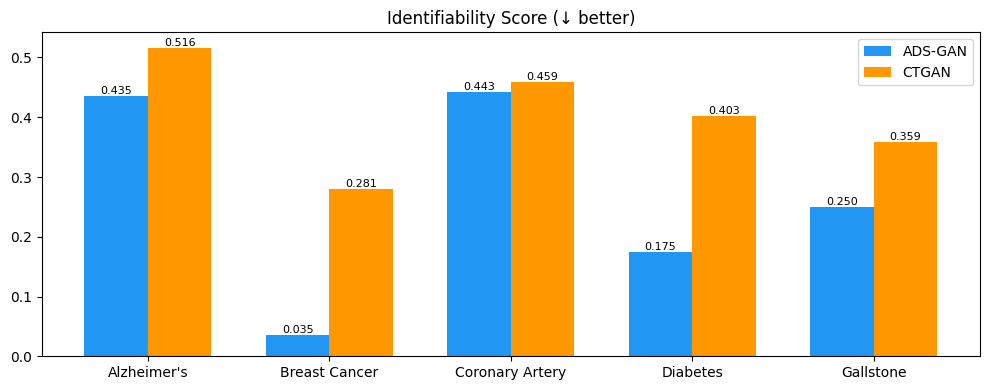

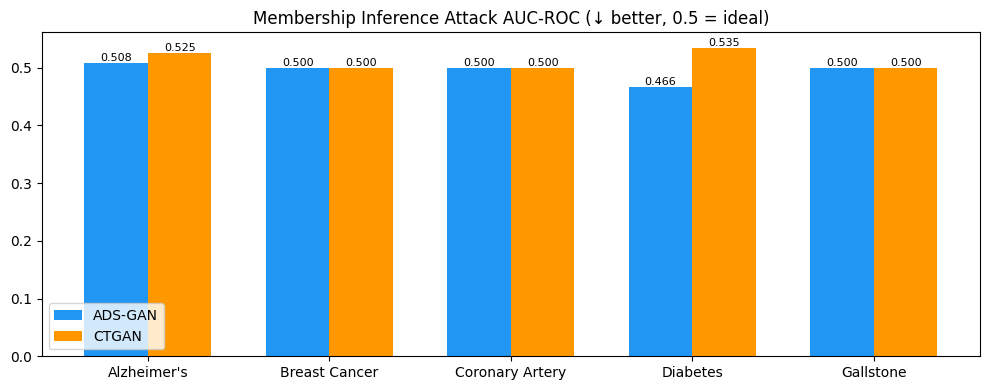

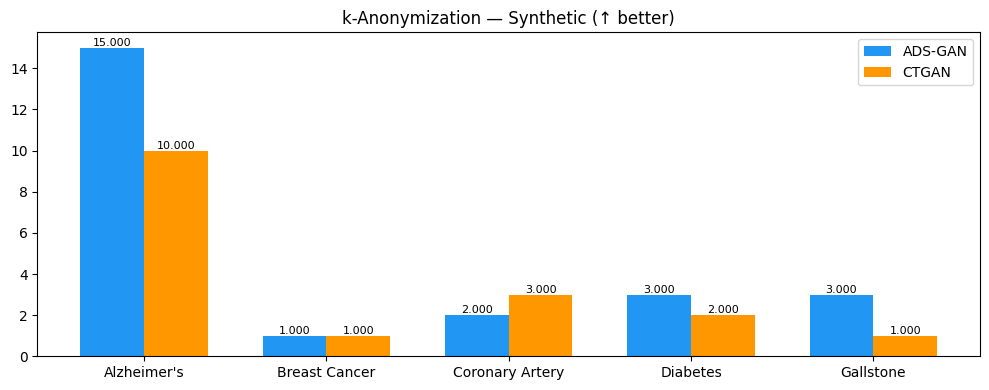

In [12]:
plot_metric_grouped('privacy.identifiability_score.score', title='Identifiability Score (↓ better)')
plot_metric_grouped('privacy.DomiasMIA_BNAF.aucroc',       title='Membership Inference Attack AUC-ROC (↓ better, 0.5 = ideal)')
plot_metric_grouped('privacy.k-anonymization.syn',         title='k-Anonymization — Synthetic (↑ better)')

## Sanity

Basic checks: no copied rows, no data type mismatches, synthetic records are not trivially close or distant from real ones.

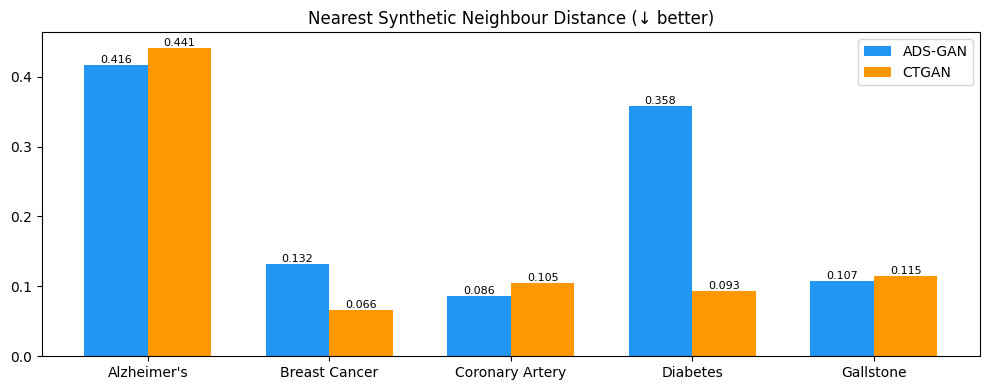

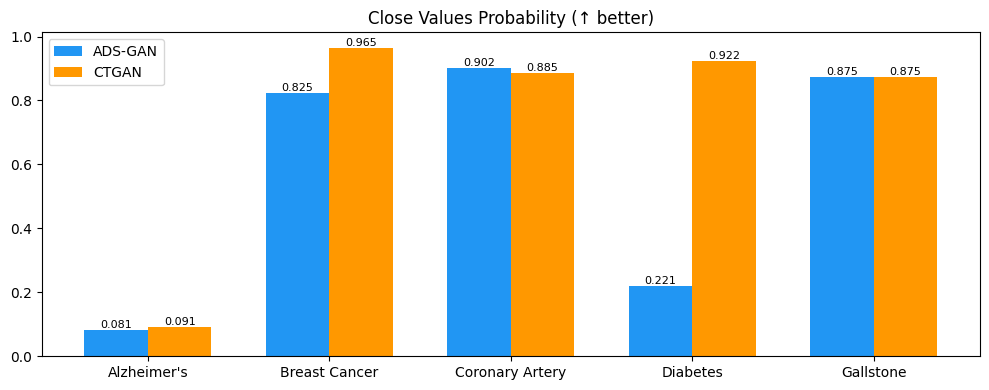

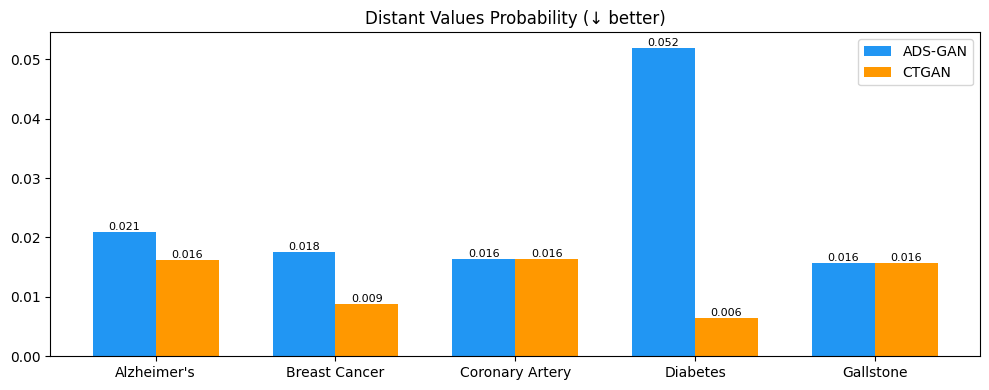

In [13]:
plot_metric_grouped('sanity.nearest_syn_neighbor_distance.mean', title='Nearest Synthetic Neighbour Distance (↓ better)')
plot_metric_grouped('sanity.close_values_probability.score',     title='Close Values Probability (↑ better)')
plot_metric_grouped('sanity.distant_values_probability.score',   title='Distant Values Probability (↓ better)')